# CNN Workshop Notebook

Simple notebook for the full workshop.

## Import Libraries

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image
from sklearn.metrics import classification_report
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

## Load Dataset

In [2]:
dataset_root = Path(r"D:\Herald College SEM-6\Artificial Intelligence and Machine Learning\workshop\workshop5\FruitinAmazon\FruitinAmazon")
train_dir = dataset_root / "train"
test_dir = dataset_root / "test"

img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2
seed = 123

print("Dataset root:", dataset_root)
print("Train dir exists:", train_dir.exists())
print("Test dir exists:", test_dir.exists())

Dataset root: D:\Herald College SEM-6\Artificial Intelligence and Machine Learning\workshop\workshop5\FruitinAmazon\FruitinAmazon
Train dir exists: True
Test dir exists: True


In [3]:
train_classes = sorted([item.name for item in train_dir.iterdir() if item.is_dir()])
test_classes = sorted([item.name for item in test_dir.iterdir() if item.is_dir()])

print("Train classes:", train_classes)
print("Test classes:", test_classes)
print("Same classes:", train_classes == test_classes)

train_counts = {name: len(list((train_dir / name).glob("*"))) for name in train_classes}
test_counts = {name: len(list((test_dir / name).glob("*"))) for name in test_classes}

print("\nTrain image counts")
for name, count in train_counts.items():
    print(f"{name}: {count}")

print("\nTest image counts")
for name, count in test_counts.items():
    print(f"{name}: {count}")

Train classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Test classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Same classes: True

Train image counts
acai: 15
cupuacu: 15
graviola: 15
guarana: 15
pupunha: 15
tucuma: 15

Test image counts
acai: 5
cupuacu: 5
graviola: 5
guarana: 5
pupunha: 5
tucuma: 5


## Task 1: View Images

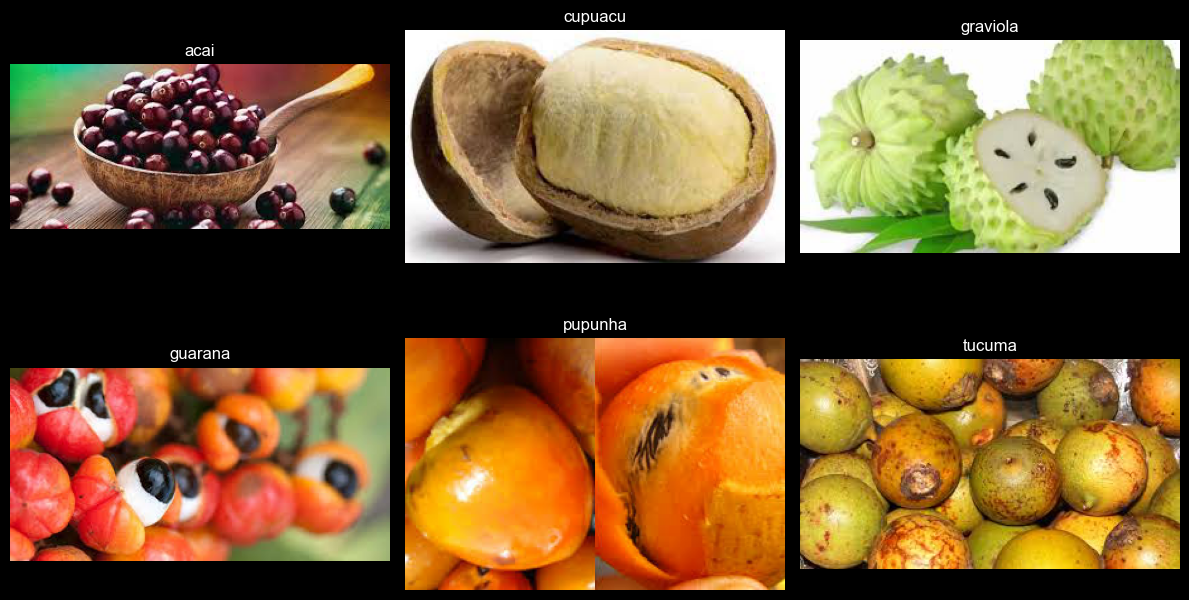

In [4]:
sample_paths = []
for class_name in train_classes:
    class_files = [p for p in (train_dir / class_name).iterdir() if p.is_file()]
    sample_paths.append(random.choice(class_files))

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for ax, image_path in zip(axes, sample_paths):
    image = Image.open(image_path)
    ax.imshow(image)
    ax.set_title(image_path.parent.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

Observation: The fruits look different in shape and color, but some images may still be hard to classify because the dataset is small.

## Task 1: Check Corrupted Images

In [5]:
corrupted_images = []

for class_name in train_classes:
    for image_path in (train_dir / class_name).iterdir():
        if not image_path.is_file():
            continue
        try:
            with Image.open(image_path) as image:
                image.verify()
        except Exception:
            corrupted_images.append(image_path)

if corrupted_images:
    for image_path in corrupted_images:
        image_path.unlink()
        print(f"Removed corrupted image: {image_path}")
else:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


## Task 2: Preprocess Data

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    validation_split=validation_split,
    subset="training",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    validation_split=validation_split,
    subset="validation",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [7]:
normalization_layer = layers.Rescaling(1.0 / 255)
autotune = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=autotune)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=autotune)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=autotune)

train_ds = train_ds.cache().prefetch(buffer_size=autotune)
val_ds = val_ds.cache().prefetch(buffer_size=autotune)
test_ds = test_ds.cache().prefetch(buffer_size=autotune)

## Build Model

In [8]:
model = keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## Train Model

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [10]:
best_model_path = Path("best_fruit_cnn_model.h5")

callbacks = [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
    ModelCheckpoint(filepath=best_model_path, monitor="val_loss", save_best_only=True),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=callbacks,
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.1958 - loss: 2.0458

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - accuracy: 0.1667 - loss: 2.1192 - val_accuracy: 0.1111 - val_loss: 1.8055
Epoch 2/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1276 - loss: 1.8214

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.2083 - loss: 1.7648 - val_accuracy: 0.2222 - val_loss: 1.7883
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3545 - loss: 1.6627

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.3194 - loss: 1.6682 - val_accuracy: 0.4444 - val_loss: 1.6368
Epoch 4/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5755 - loss: 1.4072

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5278 - loss: 1.3577 - val_accuracy: 0.3333 - val_loss: 1.4714
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7240 - loss: 1.0299

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6667 - loss: 1.0336 - val_accuracy: 0.3333 - val_loss: 1.4544
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.7639 - loss: 0.7630 - val_accuracy: 0.4444 - val_loss: 1.5526
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8750 - loss: 0.4527 - val_accuracy: 0.3889 - val_loss: 1.6252
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9583 - loss: 0.2624 - val_accuracy: 0.3889 - val_loss: 2.4089
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9028 - loss: 0.2397 - val_accuracy: 0.4444 - val_loss: 1.5868
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9722 - loss: 0.1234 - val_accuracy: 0.4444 - val_loss: 2.0275
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 1.0000 - loss: 0.0453 - val_accuracy: 0.2778 - val_loss: 2.0442
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 0.0286 - val_accuracy: 0.4444 - val_loss: 2.5152
E

## Plot Results

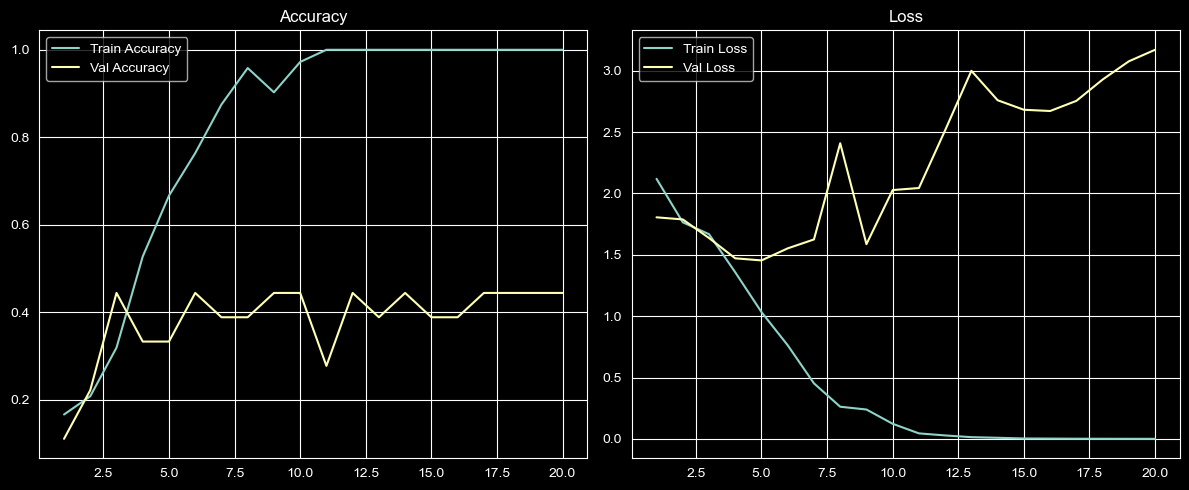

In [11]:
history_dict = history.history
epochs_range = range(1, len(history_dict["loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_dict["accuracy"], label="Train Accuracy")
plt.plot(epochs_range, history_dict["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_dict["loss"], label="Train Loss")
plt.plot(epochs_range, history_dict["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Test Model

In [12]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6000 - loss: 1.1326
Test Loss: 1.1326
Test Accuracy: 0.6000


## Save and Load Model

In [13]:
final_model_path = Path("fruit_cnn_model.h5")
model.save(final_model_path)

loaded_model = keras.models.load_model(final_model_path)
loaded_loss, loaded_accuracy = loaded_model.evaluate(test_ds)

print(f"Loaded Test Loss: {loaded_loss:.4f}")
print(f"Loaded Test Accuracy: {loaded_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6000 - loss: 1.1326 
Loaded Test Loss: 1.1326
Loaded Test Accuracy: 0.6000


## Predictions

In [14]:
y_true = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)
y_pred_probs = loaded_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       0.50      0.80      0.62         5
    graviola       0.71      1.00      0.83         5
     guarana       1.00      0.20      0.33         5
     pupunha       0.62      1.00      0.77         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.60        30
   macro avg       0.60      0.60      0.54        30
weighted avg       0.60      0.60      0.54        30



Notebook complete.